In [ ]:
# >>> repo path setup (auto-added during reorg; keeps this notebook runnable from notebooks/) <<<
import os, sys
_p = os.getcwd()
while not os.path.isdir(os.path.join(_p, 'src')) and os.path.dirname(_p) != _p:
    _p = os.path.dirname(_p)
os.chdir(_p)
sys.path.insert(0, os.path.join(_p, 'src'))
# <<< end repo path setup >>>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import arviz as az
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm

from seisfwi.model import AcousticModel, RockPhysicsGassmann
import seisfwi.defaults as defaults

from utils.vae import VanillaVAE
from utils.project_plots import configure_plot_settings
from utils.project_utils import rockphysic_inversion
from utils import RockPhysicsModel

In [3]:
nz0 = 260
nx0 = 110
nz_res = 15
nx_res = 179
x_res = (np.arange(nx_res) + nx0) * 5.0
z_res = (np.arange(nz_res) + nz0) * 5.0 
extent_res=[x_res[0]/1000, x_res[-1]/1000, z_res[-1]-z_res[0], 0]

In [4]:
configure_plot_settings()
cmap_range     = {'vp': (1400, 4500)}
cmap_range_co2 = {'vp': (-125,  125)}

In [5]:
# HMC parameters
num_samples = 40000
hmc_temp = 0.025

### Rock physics inversion

In [6]:
sa_obs = np.load('model/sa_res_nz15_nx179_5m.npy')
vp_res = np.load("./model/vp_res_nz15_nx179_5m.npy")

# Parameters for rock physics model
rock_physics_params = RockPhysicsModel(vp_res)

# Gassmann fluid substitution
rockphy = RockPhysicsGassmann(**rock_physics_params)

    Brine properties: K = 2.62 GPa, rho = 1013.5368 kg/m3
      CO2 properties: K = 0.03 GPa, rho = 537.8947 kg/m3
  Mineral properties: K = 36.93 GPa, rho = 2645.1000 kg/m3
  Estimated porosity: phi = 0.1412


In [7]:
# Load VAE Model
kld_weight = 0.000015
in_channels = 1
latent_dim = 64
device = torch.device(defaults.device)
checkpoint_path = f"/net/vision/scr2/haipeng/FWI-HMC/VAE/vae_latent_dim{latent_dim}_kld_weight{kld_weight}.pth"

# Reload the model
model_vae = VanillaVAE(in_channels=in_channels, latent_dim=latent_dim).to(defaults.device)
model_vae.load_state_dict(torch.load(checkpoint_path, map_location=defaults.device))
model_vae.eval()

def decode_in_batches(model, latent_tensor, batch_size):
    """Decode latent vectors in batches to avoid GPU OOM."""
    decoded = []
    n_samples = latent_tensor.shape[0]

    with torch.no_grad():
        for i in tqdm(range(0, n_samples, batch_size), desc="Decoding batches"):
            batch = latent_tensor[i:i + batch_size]
            decoded_batch = model.decode(batch)
            decoded_batch = F.interpolate(decoded_batch, size=(15, 179), mode='bilinear', align_corners=False)
            decoded.append(decoded_batch.cpu())
            
    decoded = torch.cat(decoded, dim=0)
    # compute mean, std, p10, p50, p90
    p10 = torch.quantile(decoded, 0.1, dim=0).numpy().squeeze()
    p50 = torch.quantile(decoded, 0.5, dim=0).numpy().squeeze()
    p90 = torch.quantile(decoded, 0.9, dim=0).numpy().squeeze()
    mean = torch.mean(decoded, dim=0).numpy().squeeze()
    std = torch.std(decoded, dim=0).numpy().squeeze()
    
    decoded = decoded.numpy().squeeze()

    return decoded, mean, std, p10, p50, p90

### Compare Different Results

In [8]:
fontsize = 14
labels = ["a)", "b)", "c)", "d)"]

# ---- Setup figure ----
fig, axes = plt.subplots(4, 3, figsize=(12, 7), dpi=150, gridspec_kw={'wspace': 0.15, 'hspace': 0.25})
ims_col0, ims_col1, ims_col2, ims_col3 = [], [], [], []

for col, model in enumerate(['small', '', 'large']):

    if model == '':
        path = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-1-geophone-1-30Hz")
        sa_obs_use = np.load(f"model/sa_res_nz15_nx179_5m.npy")
    else:
        path = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-model-{model}-survey-1-geophone-1-30Hz")
        sa_obs_use = np.load(f"model/sa_res_nz15_nx179_5m_{model}.npy")

    # Load data
    latent_posterior_az = az.from_netcdf(path / f"HMC/Posterior-hmc-num-{num_samples}-temp-{hmc_temp}.nc")
    latent_posterior    = latent_posterior_az.posterior['m'].values[0]
    latent_posterior_tensor = torch.as_tensor(latent_posterior, dtype=torch.float32, device=device)
    sa_post, sa_post_mean, sa_post_std, _,  _,  _ = decode_in_batches(model_vae, latent_posterior_tensor, 512)

    # Find MAP sample
    log_prob = np.load(path / f"HMC/LogProb-hmc-num-{num_samples}-temp-{hmc_temp}.npy")
    map_id = np.argmax(log_prob)
    sa_map = sa_post[map_id]      

    # --- FWI
    ax0 = axes[0, col]
    im0 = ax0.imshow(sa_obs_use, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
    ax0.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
    ax0.set_xticks(np.arange(0.60, 1.5, 0.2))
    ax0.set_yticks([0, 25, 50])
    ax0.grid(linestyle='--', alpha=0.35, linewidth=0.6)
    ims_col0.append(im0)

    # --- MAP
    ax1 = axes[1, col]
    im1 = ax1.imshow(sa_map, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
    ax1.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
    ax1.set_xticks(np.arange(0.60, 1.5, 0.2))
    ax1.set_yticks([0, 25, 50])
    ax1.grid(linestyle='--', alpha=0.35, linewidth=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=fontsize)
    ims_col1.append(im1)

    # --- Posterior mean
    ax2 = axes[2, col]
    im2 = ax2.imshow(sa_post_mean, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
    ax2.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
    ax2.set_xticks(np.arange(0.60, 1.5, 0.2))
    ax2.set_yticks([0, 25, 50])
    ax2.grid(linestyle='--', alpha=0.35, linewidth=0.6)
    ax2.tick_params(axis='both', which='major', labelsize=fontsize)
    ims_col2.append(im2)

    # --- Posterior std
    ax3 = axes[3, col]
    im3 = ax3.imshow(sa_post_std, cmap='viridis', vmin=0, vmax=0.09, aspect='auto', extent=extent_res)
    ax3.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
    ax3.set_xticks(np.arange(0.60, 1.5, 0.2))
    ax3.set_yticks([0, 25, 50])
    ax3.grid(linestyle='--', alpha=0.35, linewidth=0.6)
    ax3.tick_params(axis='both', which='major', labelsize=fontsize)
    ims_col3.append(im3)

    # --- Column titles (top row only)
    title = ['Smaller Plume Size', 'True Plume Size', 'Larger Plume Size']
    ax0.set_title(f'{title[col]}', fontsize=fontsize-2)
    ax0.text(-0.1, 1.19, labels[col], va='center', fontsize=fontsize+4, transform=ax0.transAxes, color='k', fontweight='bold')

    # Labels
    ax3.set_xlabel("Distance (km)", fontsize=fontsize)
    if col == 0:
        ax0.set_ylabel("Depth (m)", fontsize=fontsize)
        ax1.set_ylabel("Depth (m)", fontsize=fontsize)
        ax2.set_ylabel("Depth (m)", fontsize=fontsize)
        ax3.set_ylabel("Depth (m)", fontsize=fontsize)
    
    # close ticks for unnecessary plots
    if col != 0:
        ax0.set_yticklabels([])
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        ax3.set_yticklabels([])
        
    ax0.set_xticklabels([])
    ax1.set_xticklabels([])
    ax2.set_xticklabels([])

    # --- Axis labels
    if col == 0:
        for iii, label in enumerate(["Target", "MAP", "Posterior Mean", "Posterior SD"]):
            axes[iii, 0].text(0.02, 0.1, label, va='center', fontsize=fontsize-2, transform=axes[iii, 0].transAxes, color='w', fontweight='bold')
            
        # ---- Two equal colorbars at the bottom (outside loop) ----
        cax_vel = fig.add_axes([0.12, -0.005, 0.35, 0.02])  # left half
        cax_std = fig.add_axes([0.55, -0.005, 0.35, 0.02])  # right half

        cbar_sat = fig.colorbar(ims_col0[0], cax=cax_vel, orientation='horizontal')
        cbar_sat.ax.tick_params(labelsize=fontsize)
        cbar_sat.set_label("Saturation", fontsize=fontsize)
            
        cbar_std = fig.colorbar(ims_col3[0], cax=cax_std, orientation='horizontal')
        cbar_std.ax.tick_params(labelsize=fontsize)
        cbar_std.set_label("Saturation SD", fontsize=fontsize)
        cbar_std.set_ticks([0, 0.03, 0.06, 0.09])

save_path = f"figures/FWI-HMC-Error-survey-1-geophone-1-f0-30-num-{num_samples}-temp-{hmc_temp}.png"
if save_path:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
else:
    plt.show()

Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 49.38it/s]


### Wrong Rock Physics

In [9]:
path = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-model-new-survey-1-geophone-1-30Hz")

# Load data
latent_posterior_az = az.from_netcdf(path / f"HMC/Posterior-hmc-num-{num_samples}-temp-{hmc_temp}.nc")
latent_posterior    = latent_posterior_az.posterior['m'].values[0]
latent_posterior_tensor = torch.as_tensor(latent_posterior, dtype=torch.float32, device=device)
sa_post, sa_post_mean, sa_post_std, sa_post_p10, sa_post_p50, sa_post_p90 = decode_in_batches(model_vae, latent_posterior_tensor, 512)

# Find MAP sample
log_prob = np.load(path / f"HMC/LogProb-hmc-num-{num_samples}-temp-{hmc_temp}.npy")
map_id = np.argmax(log_prob)
sa_map = sa_post[map_id]      

# FWI
model_bl  = AcousticModel.load(path/"Model-BL.npz")
model_fwi = AcousticModel.load(path/"Model-FWI.npz")
sa_fwi = np.load(path/"Model-FWI-Sat.npy").reshape(15, 179)

vp_fwi = model_fwi.get_model('vp') - model_bl.get_model('vp')
vp_fwi = vp_fwi[nz0:nz0+nz_res, nx0:nx0+nx_res]
sa_fwi_inv = rockphysic_inversion(rockphy, vp_fwi, max_iter = 100, verbose=True)

sa_obs_use = np.load(f"model/sa_res_nz15_nx179_5m.npy")

Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 49.13it/s]


Iteration 0001/100: Loss = 15459.35
Iteration 0011/100: Loss = 8094.45
Iteration 0021/100: Loss = 3742.41
Iteration 0031/100: Loss = 1563.07
Iteration 0041/100: Loss = 626.32
Iteration 0051/100: Loss = 267.99
Iteration 0061/100: Loss = 135.76
Iteration 0071/100: Loss = 84.20
Iteration 0081/100: Loss = 62.65
Iteration 0091/100: Loss = 53.46
Iteration 0100/100: Loss = 49.80


In [12]:
def draw(ax, xind, map_, mean_, p10_, p90_, dfwi, title=None, legend=False, ylabel=False, xlabel=False):
    # Line colors

    ax.plot(sa_obs[:, xind], z_res-z_res[0], label='True',           color="#d73027" , linewidth=2)
    ax.plot(dfwi[:, xind], z_res-z_res[0], label='MLE', color='blue', linewidth=2.0, linestyle='-')
    ax.plot(map_[:, xind],  z_res-z_res[0],  label='MAP',            color="cyan",    linewidth=2, zorder=10)
    ax.plot(mean_[:, xind],  z_res-z_res[0], label='Posterior Mean', color="k",    linewidth=2, zorder=10)
    ax.fill_betweenx(z_res-z_res[0], p10_[:, xind], p90_[:, xind], color="#feb24c", alpha=0.4, label='80% CI')

    ax.set_ylim([z_res[-1]-z_res[0], 0])
    ax.set_xlim([-0.02, 0.6])
    # ax.set_yticks(np.arange(0.75, 0.91, 0.05))
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)
    if xlabel: ax.set_xlabel(r'Saturation', fontsize=fontsize)
    if ylabel: ax.set_ylabel('Reservoir depth (m)', fontsize=fontsize)
    if title:  ax.set_title(title, fontsize=fontsize, pad=6)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    if legend: ax.legend(fontsize=fontsize-3, loc='lower right', frameon=True, ncol=1)

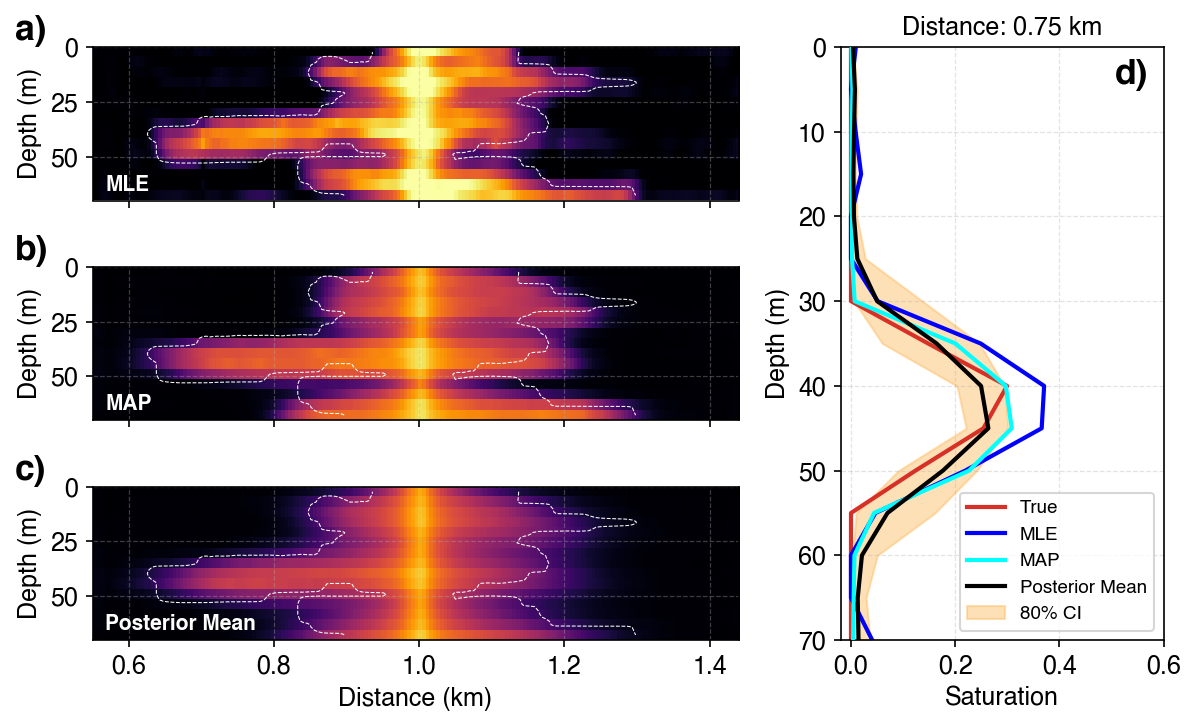

In [13]:
fig = plt.figure(figsize=(8, 5), dpi=150)
gs = gridspec.GridSpec(3, 2, figure=fig, width_ratios=[2, 1])

fontsize = 12

# (a) FWI
ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(sa_fwi_inv, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
ax0.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
ax0.set_xticks(np.arange(0.60, 1.5, 0.2))
ax0.grid(linestyle='--', alpha=0.35, linewidth=0.6)
ax0.text(0.02, 0.1, 'MLE', va='center', fontsize=fontsize-2, transform=ax0.transAxes, color='w', fontweight='bold')
ax0.set_yticks([0, 25, 50])
ax0.set_xticklabels([])

# (b) MAP
ax1 = fig.add_subplot(gs[1, 0])
im1 = ax1.imshow(sa_map, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
ax1.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
ax1.set_xticks(np.arange(0.60, 1.5, 0.2))
ax1.grid(linestyle='--', alpha=0.35, linewidth=0.6)
ax1.text(0.02, 0.1, 'MAP', va='center', fontsize=fontsize-2, transform=ax1.transAxes, color='w', fontweight='bold')
ax1.set_yticks([0, 25, 50])
ax1.set_xticklabels([])

# (c) Posterior Mean
ax2 = fig.add_subplot(gs[2, 0])
im2 = ax2.imshow(sa_post_mean, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
ax2.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
ax2.set_xticks(np.arange(0.60, 1.5, 0.2))
ax2.grid(linestyle='--', alpha=0.35, linewidth=0.6)
ax2.text(0.02, 0.1, 'Posterior Mean', va='center', fontsize=fontsize-2, transform=ax2.transAxes, color='w', fontweight='bold')
ax2.set_yticks([0, 25, 50])

# Labels
ax2.set_xlabel("Distance (km)", fontsize=fontsize)
ax0.set_ylabel("Depth (m)", fontsize=fontsize)
ax1.set_ylabel("Depth (m)", fontsize=fontsize)
ax2.set_ylabel("Depth (m)", fontsize=fontsize)

# (d) PROFILE PLOTS (Wide plot spanning 2nd column)
ax3 = fig.add_subplot(gs[:, 1])   # spans all rows, right column
dists = [750]
x_inds = [np.argmin(np.abs(x_res - d)) for d in dists]

draw(ax3,
     x_inds[0],
     sa_map,
     sa_post_mean,
     sa_post_p10,
     sa_post_p90,
     sa_fwi_inv,
     f'Distance: {dists[0]/1000:.2f} km',
     True, True)

ax3.set_ylabel("Depth (m)", fontsize=fontsize)
ax3.set_xlabel("Saturation")

for ax in [ax0, ax1, ax2, ax3]:
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.grid(linestyle='--', alpha=0.35, linewidth=0.6)

for i, ax in enumerate([ax0, ax1, ax2]):
     ax.text(-0.12, 1., labels[i], transform=ax.transAxes, fontsize=fontsize+5, fontweight='bold', ha='left', va='bottom')

ax3.text(0.85, 0.98, 'd)', transform=ax3.transAxes, fontsize=fontsize+5, va='top', ha='left', color='black', fontweight='bold')

plt.tight_layout()
plt.savefig(f"figures/FWI-HMC-Rock-Physics-temp-{hmc_temp}-f0-30Hz.png", dpi=300, bbox_inches='tight')
plt.show()
